In [14]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from src.base.data import generate_data

x, y_true, y_noise = generate_data(200, noise_std=0.3)

In [ ]:
import torch
from src.base.diffusion_utils import prepare_noise_schedule, q_sample

num_steps = 100
_, _, alpha_bars = prepare_noise_schedule(num_steps)

y_clean_torch = torch.tensor(y_true, dtype=torch.float32)

t = torch.randint(0, num_steps, (len(y_clean_torch),))

y_t, noise = q_sample(y_clean_torch, t, alpha_bars)

print(y_t.shape)
print(noise.shape)

torch.Size([200, 1])
torch.Size([200, 1])


In [ ]:
import torch

from src.base.diffusion_model import DiffusionModel
from src.base.train_diffusion import train_diffusion

x_torch = torch.tensor(x, dtype=torch.float32)
y_clean_torch = torch.tensor(y_true, dtype=torch.float32)

model = DiffusionModel()

model, losses, alpha_bars = train_diffusion(
    model,
    x_torch,
    y_clean_torch,
    num_steps=100,
    epochs=1000,
    lr=1e-3
)

torch.Size([200, 3])
Epoch 0: loss = 0.974067
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Siz

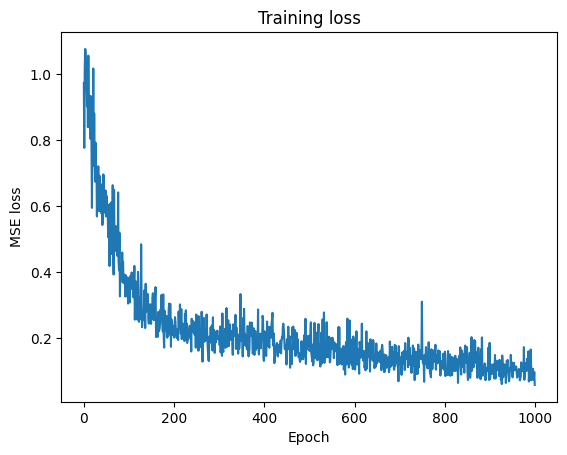

In [18]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.show()

In [19]:
def denoise_once(model, x, y_t, t, num_steps):
    t_norm = torch.full((len(x),), t / (num_steps - 1), dtype=x.dtype, device=x.device)

    pred_noise = model(x, y_t, t_norm).squeeze(1)

    y_denoised = y_t - pred_noise

    return y_denoised

In [20]:
y_t = torch.randn_like(x_torch)

num_steps = 100
t = num_steps - 1

y_pred_diff = denoise_once(model, x_torch, y_t, t, num_steps)
y_pred_diff = y_pred_diff.detach().numpy().flatten()

torch.Size([200, 3])


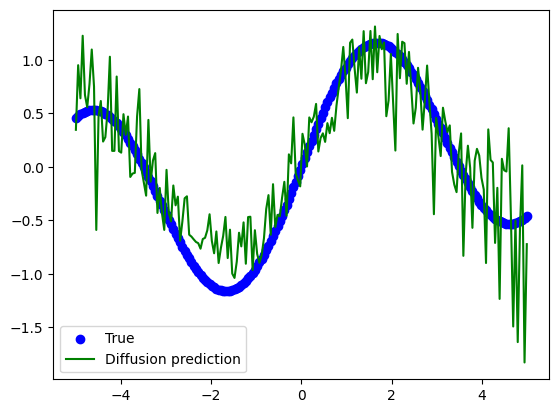

In [21]:
plt.scatter(x, y_true, label="True", color='blue')

plt.plot(x, y_pred_diff, label="Diffusion prediction", color='green')

plt.legend()
plt.show()

In [22]:
def sample_diffusion(model, x, num_steps, alpha_bars):
    model.eval()

    with torch.no_grad():
        x = x.float()
        y_t = torch.randn_like(x)

        for t in reversed(range(num_steps)):
            t_tensor = torch.full((len(x),), t / (num_steps - 1), dtype=x.dtype)

            pred_noise = model(x, y_t, t_tensor).squeeze(1)

            alpha_bar_t = alpha_bars[t]

            y_t = (y_t - pred_noise * torch.sqrt(1 - alpha_bar_t)) / torch.sqrt(alpha_bar_t)

        return y_t

In [23]:
y_pred_diff = sample_diffusion(model, x_torch, num_steps, alpha_bars)

y_pred_diff = y_pred_diff.detach().numpy()

torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([200, 3])
torch.Size([2

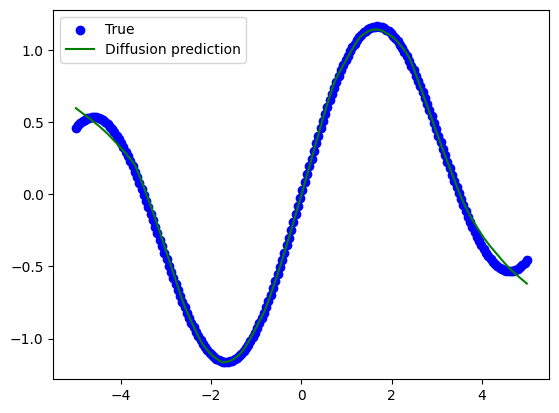

In [24]:
plt.scatter(x, y_true, label="True", color='blue')

plt.plot(x, y_pred_diff, label="Diffusion prediction", color='green')

plt.legend()
plt.show()